# Knowing about executions on the tree

## Introduction

This notebook shall provide a tutorial on how to define your own execution functions and model to execute them. To do this, we shall use a concrete example: **estimation of inner nodes**, which is a classical problem is the field of phylogenetic comparative methods, that is, **given the topology of a phylogenetic tree and observations at its leaf nodes, how to estimate the rest of nodes in this tree?** 

To begin with, we shall use a simple estimation model: **any non-leaf node can be estimated as the weighted mean of its children**, i.e.
$$
\hat{x} = \sum^k_{i=1} \frac{1}{w_i} x^{\text{ch}(x)}_i,
$$
where $\hat{x}$ is the estimation of current node, and $x^{\text{ch}(x)}_i$ is the $i$-th child of the current node, $w_i$ is the length of edge between the node and its $i$-th child (in a phylogenetic tree, it normally has a physical meaning of evolutionary period length). To make it even simpler, we shall assume all the node values are scalars.

## Executions on the tree

Generally the executions on the tree can be categorized by their directions:
1) **Downwards**: given the current node, compute its children;
2) **Upwards**: given a set of children with a common parent, compute the parent based on its children.

**Downwards** execution is relatively simpler as the updates of each child is independent as it only depends on the considered child and its parent, so it can be processed completely individually. However, it does not apply to **Upwards** executions, since the updates of common parent depends on the information from all its children, which can not be done unless after gathering all the children. `Hyperiax` provides you with several clear-to-use interfaces to handle both types of executions without need to consider the actual distributing and grouping operations, all the executions can be defined locally, and `hyperiax.execution` module will handle the rest complicated stuffs.

## Content of this notebook

In this notebook, we will walk through several actual implementations that use the feature of `Hyperiax`, including:
* Defining and simulating a tree downwards using `down_fn`
* Estimating the non-leaf nodes from simulation using `up_fn`, `transform_fn`.

In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib inline

In [2]:
from rich import print
import jax
import jax.numpy as jnp
import jax.random as jr
import matplotlib.pyplot as plt

from hyperiax.tree import HypTree
from hyperiax.tree.topology import symmetric_topology
from hyperiax.models import DownLambda, UpLambda, UpLambdaReducer
from hyperiax.execution import OrderedExecutor

## Creating and simulating the tree

We initialize a `HypTree` from a chosen `topo`, as introduced in the previous tree building tutorial.

In [3]:
# We create a symmetric binary tree of height 4 (including root level), the `height` argument is computed excluding the root level, therefore, 3.
topo = symmetric_topology(height=3, degree=2)
tree = HypTree(topo)
print(tree)

HypTree:
Topology:
       o
   ┌───┴───┐
   o       o   
 ┌─┴─┐   ┌─┴─┐ 
 o   o   o   o 
┌┴┐ ┌┴┐ ┌┴┐ ┌┴┐
o o o o o o o o
Statistics:
total number of nodes = 15
number of levels = 4
number of leaves = 8
number of inner nodes = 6

Next, we need to specify which kind of data we intend to store in the tree nodes. In this example we model the connection between an inner node and its child follows a **Brownian motion**, that is, the value $x^{\text{ch}(x)}$ of a child $\text{ch}(x)$ is sampled from a standard Brownian motion that starts from $x$ and lasts for $T$:
$$
x^{\text{ch}(x)} = x + \sqrt{T} \cdot \epsilon, \quad \epsilon \sim \mathcal{N}(0, 1). 
$$
Therefore, we need the following properties for each node:
* `x`: value of the node $x$;
* `T`: Brownian motion running period length $T$, also is the length of edge between the node and its parent;
* `epsilon`: noise added in Brownian motion sampling $\epsilon$.

They are all scalars.

In [4]:
tree.add_property("x", shape=())
tree.add_property("T", shape=())
tree.add_property("epsilon", shape=())

All the data in nodes are stored in a single large `jax.Array` with shape `(num_nodes, d)`, indexing by their names as keys. `tree.data` is a `dict` that contains all types of data in the tree. By default, when initialize a certain type of data, it is all set to *zeros*. Then, it can be modified by `JAX`'s Array update `x.at[idx].set(y)`.

For now, we need to initialize `T` and `epsilon` to prepare for the simulation. 

For `T`s, we want to set it to be a decaying values as a function of the node depth, so that the deeper the node, the shorter the edge length. Let's use:
$$
T = \exp (-\log(2) * d),
$$
where $d$ is the depth of the node.

For `epsilon`s, we simply use `jax.random.normal` to draw them independently from a standard normal distribution.

In [5]:
key = jr.key(42)

tree.data["T"] = jnp.exp(-jnp.log(2.0) * tree.node_depths)
tree.data["epsilon"] = jr.normal(key, shape=tree.data["epsilon"].shape)

In [6]:
print(tree.data)

{
    'x': Array([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.],      dtype=float32),
    'T': Array([1.   , 0.5  , 0.5  , 0.25 , 0.25 , 0.25 , 0.25 , 0.125, 0.125,
       0.125, 0.125, 0.125, 0.125, 0.125, 0.125],      dtype=float32, weak_type=True),
    'epsilon': Array([-0.02830462,  0.46713185,  0.29570296,  0.15354592, -0.12403282,
        0.21692315, -1.440879  ,  0.7558599 ,  0.52140963,  0.9101704 ,
       -0.3844966 ,  1.1398233 ,  1.4457862 ,  1.0809066 , -0.05629321],      dtype=float32)
}

In [6]:
@jax.jit
def down_fn(current_T, current_epsilon, parent_x, params_dict):
    return {'x': jnp.sqrt(current_T) * parent_x + current_epsilon}

In [7]:
down_model = DownLambda(down_fn)
down_exe = OrderedExecutor(down_model)
down_exe.down(tree)

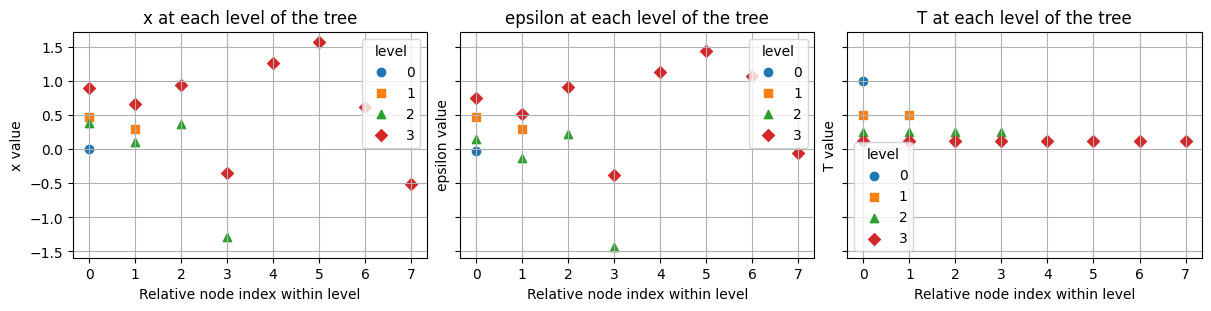

In [8]:
fig, axs = plt.subplots(1, 3, figsize=(12, 3), layout="constrained", sharex=True, sharey=True)
markers = ['o', 's', '^', 'D', 'x', 'v', 'P', '*', 'H', '+']
for i, (l_start, l_end) in enumerate(tree.levels):
    level_x = tree.data['x'][l_start:l_end]
    level_epsilon = tree.data['epsilon'][l_start:l_end]
    level_T = tree.data['T'][l_start:l_end]
    axs[0].scatter(jnp.arange(0, l_end-l_start), level_x, label=f"{i}", marker=markers[i % len(markers)])
    axs[1].scatter(jnp.arange(0, l_end-l_start), level_epsilon, label=f"{i}", marker=markers[i % len(markers)])
    axs[2].scatter(jnp.arange(0, l_end-l_start), level_T, label=f"{i}", marker=markers[i % len(markers)])
axs[0].set_xlabel("Relative node index within level")
axs[0].set_ylabel("x value")
axs[0].set_xticks(jnp.arange(0, l_end-l_start))
axs[0].legend(title='level')
axs[0].grid()
axs[0].set_title("x at each level of the tree")

axs[1].set_xlabel("Relative node index within level")
axs[1].set_ylabel("epsilon value")
axs[1].set_xticks(jnp.arange(0, l_end-l_start))
axs[1].legend(title='level')
axs[1].grid()
axs[1].set_title("epsilon at each level of the tree")

axs[2].set_xlabel("Relative node index within level")
axs[2].set_ylabel("T value")
axs[2].set_xticks(jnp.arange(0, l_end-l_start))
axs[2].legend(title='level')
axs[2].grid()
axs[2].set_title("T at each level of the tree")
plt.show()

In [9]:
tree.add_property("x_hat", shape=())
tree.add_property("x_avg", shape=())
tree.add_property("inv_T", shape=())
leaf_x = tree.data['x'][tree.is_leaf]
tree.data['x_hat'] = tree.data['x_hat'].at[tree.is_leaf].set(leaf_x)
print(f"tree.data['x_hat']:\n{tree.data['x_hat']}")
print(f"tree.data['x_avg']:\n{tree.data['x_avg']}")
print(f"tree.data['inv_T']:\n{tree.data['inv_T']}")

tree.data['x_hat']:
[ 0.          0.          0.          0.          0.          0.
  0.          0.89272463  0.65827435  0.94889617 -0.3457708   1.2687906
  1.5747535   0.62375236 -0.51344746]

tree.data['x_avg']:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

tree.data['inv_T']:
[0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]

In [17]:
@jax.jit
def up_fn(current_x_hat, current_T, params_dict):
    return {
        'x_avg': current_x_hat / current_T,
        'inv_T': 1.0 / current_T
    }
    
@jax.jit
def transform_fn(current_x_avg, current_inv_T, params_dict):
    return {
        'x_hat': current_x_avg / current_inv_T
    }

In [18]:
up_reduce_model = UpLambdaReducer(
    up_fn, transform_fn, 
    reductions={
        'x_avg': 'sum',
        'inv_T': 'sum'
    },
    up_preserves=[]
)
up_reduce_exe = OrderedExecutor(up_reduce_model)
up_reduce_exe.up(tree)

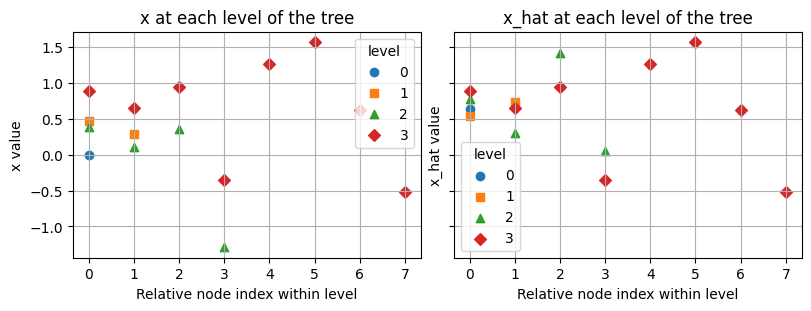

In [19]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), layout="constrained", sharex=True, sharey=True)
for i, (l_start, l_end) in enumerate(tree.levels):
    level_x = tree.data['x'][l_start:l_end]
    level_x_hat = tree.data['x_hat'][l_start:l_end]
    axs[0].scatter(jnp.arange(0, l_end-l_start), level_x, label=f"{i}", marker=markers[i % len(markers)])
    axs[1].scatter(jnp.arange(0, l_end-l_start), level_x_hat, label=f"{i}", marker=markers[i % len(markers)])
axs[0].set_xlabel("Relative node index within level")
axs[0].set_ylabel("x value")
axs[0].set_xticks(jnp.arange(0, l_end-l_start))
axs[0].legend(title='level')
axs[0].grid()
axs[0].set_title("x at each level of the tree")

axs[1].set_xlabel("Relative node index within level")
axs[1].set_ylabel("x_hat value")
axs[1].set_xticks(jnp.arange(0, l_end-l_start))
axs[1].legend(title='level')
axs[1].grid()
axs[1].set_title("x_hat at each level of the tree")
plt.show()

In [20]:
precomputed_tree = HypTree(topo, precompute_child_gathers=True)
precomputed_tree.data = tree.data.copy()

In [21]:
@jax.jit
def fast_up_fn(child_x_hat, child_T, params_dict):
    inv_T = 1. / child_T
    norm = inv_T.sum(axis=1)
    current_x_hat = jnp.einsum('bc,bc->b', child_x_hat, inv_T) / norm
    return {
        'x_hat': current_x_hat
    } 

In [22]:
up_model = UpLambda(fast_up_fn)
up_exe = OrderedExecutor(up_model)
up_exe.up(precomputed_tree)

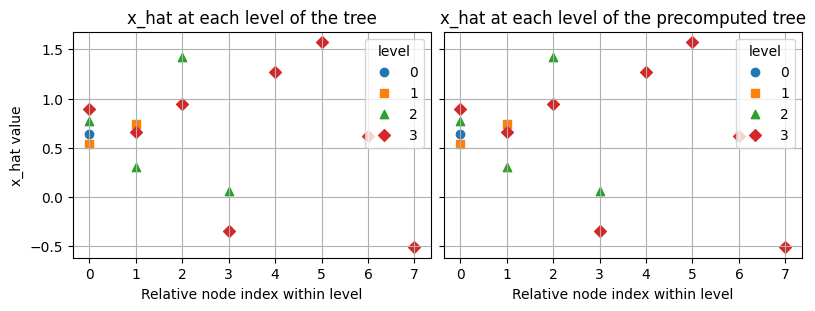

In [23]:
fig, axs = plt.subplots(1, 2, figsize=(8, 3), layout="constrained", sharex=True, sharey=True)
for i, (l_start, l_end) in enumerate(tree.levels):
    level_x_hat = tree.data['x_hat'][l_start:l_end]
    level_x_hat_precomputed = precomputed_tree.data['x_hat'][l_start:l_end]
    axs[0].scatter(jnp.arange(0, l_end-l_start), level_x_hat, label=f"{i}", marker=markers[i % len(markers)])
    axs[1].scatter(jnp.arange(0, l_end-l_start), level_x_hat_precomputed, label=f"{i}", marker=markers[i % len(markers)])
axs[0].set_xlabel("Relative node index within level")
axs[0].set_ylabel("x_hat value")
axs[0].set_xticks(jnp.arange(0, l_end-l_start))
axs[0].legend(title='level')
axs[0].grid()
axs[0].set_title("x_hat at each level of the tree")

axs[1].set_xlabel("Relative node index within level")
axs[1].set_xticks(jnp.arange(0, l_end-l_start))
axs[1].legend(title='level')
axs[1].grid()
axs[1].set_title("x_hat at each level of the precomputed tree")
plt.show()

In [24]:
print((tree.data['x_hat'] == precomputed_tree.data['x_hat']).all())

True